In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import trapezoid, simpson
from scipy.special import roots_legendre

# Zadanie 1

Wiadomo, że:
$$ \int_{0}^{1} \frac{4}{1+x^2} \,dx = \pi \ \text{.} \tag{1} $$
Powyższą równość można wykorzystać do obliczenia przybliżonej wartości $\pi$ poprzez całkowanie numeryczne.

In [14]:
def f(x):
    return 4 / (1 + x ** 2)

#### Wzór prostokątów


In [15]:
def midpoint_rule(y, x):
    """
    y: Input array to integrate.
    x: The sample points corresponding to the y values.
    """
    # result = .0
    # for i in range(len(y) - 1):
    #     result += (x[i + 1] - x[i]) * y[i]
    # return result
    return np.sum(y[:-1] * (x[1:] - x[:-1]))

### a)

Oblicz wartość powyższej całki, korzystając ze złożonych kwadratur otwartej prostokątów (ang. mid-point rule), trapezów i Simpsona. Można wykorzystać funkcje `integrate.trapz` i `integrate.simps` z biblioteki `scipy`. Na przedziale całkowania rozmieść $2^m+1$ równoodległych węzłów. W kolejnych próbach $m$ wzrasta o $1$, tzn. między każde dwa sąsiednie węzły dodawany jest nowy węzeł, a ich zagęszczenie zwiększa się dwukrotnie. Przyjmij zakres wartości $m$ od $1$ do $25$.

In [16]:
m_values = 2**np.arange(1, 26) + 1
a = 0
b = 1

error_midpoint = np.empty_like(m_values, dtype=np.float64)
error_trapzoid = np.empty_like(m_values, dtype=np.float64)
error_simpson = np.empty_like(m_values, dtype=np.float64)

for i, m in enumerate(m_values):
    xs = np.linspace(a, b, m)
    ys = f(xs)

    result_midpoint = midpoint_rule(x=xs, y=ys)
    result_trapz = trapezoid(x=xs, y=ys)
    result_simps = simpson(x=xs, y=ys)

    error_midpoint[i] = np.abs(result_midpoint - np.pi) / np.pi
    error_trapzoid[i] = np.abs(result_trapz - np.pi) / np.pi
    error_simpson[i] = np.abs(result_simps - np.pi) / np.pi

Dla każdej metody narysuj wykres wartości bezwzględnej błędu względnego w zależności od liczby ewaluacji funkcji podcałkowej, $n + 1$ (gdzie $n = 1/h$, z krokiem $h$). Wyniki przedstaw na wspólnym wykresie, używając skali logarytmicznej na obu osiach.

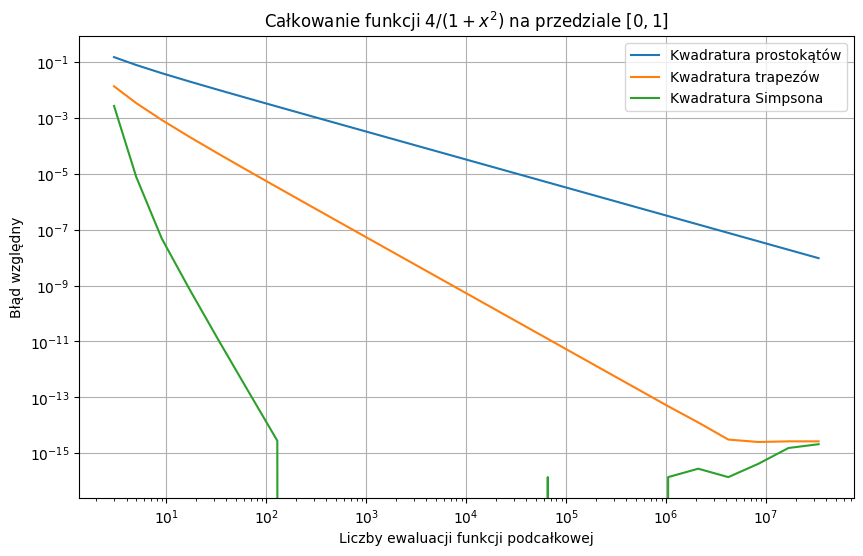

In [17]:
plt.figure(figsize=(10, 6))
plt.loglog(m_values, error_midpoint,label="Kwadratura prostokątów")
plt.loglog(m_values, error_trapzoid, label="Kwadratura trapezów")
plt.loglog(m_values, error_simpson, label="Kwadratura Simpsona")

plt.xlabel("Liczby ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title("Całkowanie funkcji $4/(1 + x^2)$ na przedziale $[0, 1]$")
plt.grid(True)
plt.legend()
plt.show()

### b)

Czy istnieje pewna wartość, poniżej której zmniejszanie kroku $h$ nie zmniejsza już błędu kwadratury? Porównaj wartość $h_{min}$, odpowiadającą minimum wartości bezwzględnej błędu względnego, z wartością wyznaczoną w laboratorium 1 ($h_\text{min} = 1\text{e-7}$).

In [18]:
h_min_midpoint = 1 / (m_values[np.argmin(error_midpoint)] + 1)
h_min_trapzoid = 1 / (m_values[np.argmin(error_trapzoid)] + 1)
h_min_simpson = 1 / (m_values[np.argmin(error_simpson)] + 1)

pd.DataFrame(
    {
        "quad_type": ["midpoint", "trapzoid", "simpson"],
        "h_min": [h_min_midpoint, h_min_trapzoid, h_min_simpson],
        "evaluations": [
            m_values[np.argmin(error_midpoint)],
            m_values[np.argmin(error_trapzoid)],
            m_values[np.argmin(error_simpson)],
        ],
        "error": [
            np.min(error_midpoint),
            np.min(error_trapzoid),
            np.min(error_simpson),
        ],
    }
).style.hide(axis="index").format({"h_min": "{:.2e}", "evaluations": "{:.2e}", "error": "{:.2e}"})

quad_type,h_min,evaluations,error
midpoint,2.98e-08,3.36e+07,9.49e-09
trapzoid,1.19e-07,8.39e+06,2.54e-15
simpson,3.88e-03,2.57e+02,0.00e+00


### c)

Dla każdej z użytych metod porównaj empiryczny rząd zbieżności z rząd zbieżności przewidywanym przez teorię. Aby wyniki miały sens, do obliczenia rzędu empirycznego użyj wartości $h$ z zakresu, w którym błąd metody przeważa nad błędem numerycznym.

In [19]:
m1_midpoint = 24
m2_midpoint = 25

m1_trapzoid = 21
m2_trapzoid = 22

m1_simpson = 6
m2_simpson = 7

h1_midpoint = 1 / (m_values[m1_midpoint - 1] + 1)
h2_midpoint = 1 / (m_values[m2_midpoint - 1] + 1)
eoc_midpoint = np.log(
    error_midpoint[m2_midpoint - 1] / error_midpoint[m1_midpoint - 1]
) / np.log(h2_midpoint / h1_midpoint)

h1_trapzoid = 1 / (m_values[m1_trapzoid - 1] + 1)
h2_trapzoid = 1 / (m_values[m2_trapzoid - 1] + 1)
eoc_trapzoid = np.log(
    error_trapzoid[m2_trapzoid - 1] / error_trapzoid[m1_trapzoid - 1]
) / np.log(h2_trapzoid / h1_trapzoid)

h1_simpson = 1 / (m_values[m1_simpson - 1] + 1)
h2_simpson = 1 / (m_values[m2_simpson - 1] + 1)
eoc_simpson = np.log(
    error_simpson[m2_simpson - 1] / error_simpson[m1_simpson - 1]
) / np.log(h2_simpson / h1_simpson)

pd.DataFrame(
    {
        "quad_type": ["midpoint", "trapzoid", "simpson"],
        "m1_evals": m_values[[m1_midpoint - 1, m1_trapzoid - 1, m1_simpson - 1]],
        "m2_evals": m_values[[m2_midpoint - 1, m2_trapzoid - 1, m2_simpson - 1]],
        "h1": [h1_midpoint, h1_trapzoid, h1_simpson],
        "h2": [h2_midpoint, h2_trapzoid, h2_simpson],
        "calc_EOC": [eoc_midpoint, eoc_trapzoid, eoc_simpson],
        "theoretical_EOC": [1, 2, 4],
    }
).style.hide(axis="index").format(
    {
        "h1": "{:.2e}",
        "h2": "{:.2e}",
        "m1_evals": "{:.0e}",
        "m2_evals": "{:.0e}",
        "calc_EOC": "{:.6f}",
    }
)

quad_type,m1_evals,m2_evals,h1,h2,calc_EOC,theoretical_EOC
midpoint,2e+07,3e+07,5.96e-08,2.98e-08,1.000000,1
trapzoid,2e+06,4e+06,4.77e-07,2.38e-07,2.032423,2
simpson,6e+01,1e+02,1.52e-02,7.69e-03,6.158006,4


# Zadanie 2

Oblicz wartość całki
$$ \int_{0}^{1} \frac{4}{1+x^2} \,dx \tag{2} $$
metodą Gaussa-Legendre’a. Narysuj wykres wartości bezwzględnej błędu względnego w zależności od liczby ewaluacji funkcji podcałkowej, $n + 1$. Przyjmij na tyle duży zakres $n$, aby wykryć, kiedy błąd numeryczny zaczyna przeważać nad błędem metody. Postaraj się umiejscowić otrzymane wyniki na wykresie stworzonym w podpunkcie (a).

In [20]:
def gauss_legendre(f, a, b, n):
    xs, ws = roots_legendre(n)
    xs_scaled = 0.5 * (b - a) * xs + 0.5 * (b + a)
    return np.sum(ws * f(xs_scaled)) * (b - a) / 2

In [21]:
gauss_legendre_values = np.arange(1, 100)
error_gauss_legendre = np.empty_like(gauss_legendre_values, dtype=np.float64)

for i, m in enumerate(gauss_legendre_values):
    result_gauss_legendre = gauss_legendre(f, 0, 1, m)

    error_gauss_legendre[i] = np.abs(result_gauss_legendre - np.pi) / np.pi

# pd.DataFrame(
#     {
#         "quadrature_order": gauss_legendre_values,
#         "error": error_gauss_legendre,
#     }
# ).style.hide(axis="index").format({"error": "{:.2e}"})

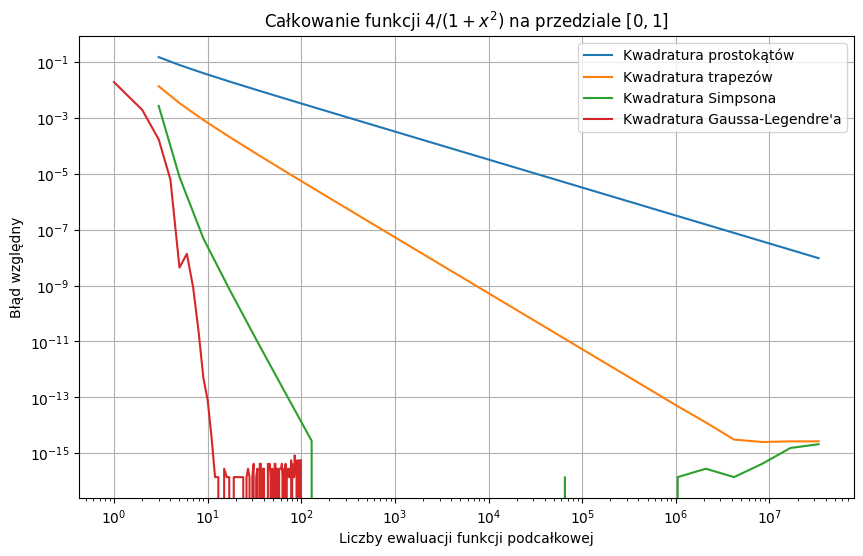

In [22]:
plt.figure(figsize=(10, 6))
plt.loglog(m_values, error_midpoint,label="Kwadratura prostokątów")
plt.loglog(m_values, error_trapzoid, label="Kwadratura trapezów")
plt.loglog(m_values, error_simpson, label="Kwadratura Simpsona")
plt.loglog(gauss_legendre_values, error_gauss_legendre, label="Kwadratura Gaussa-Legendre'a")

plt.xlabel("Liczby ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title("Całkowanie funkcji $4/(1 + x^2)$ na przedziale $[0, 1]$")
plt.grid(True)
plt.legend()
plt.show()